
### 코드 설명

1. **CIFAR-100 사전학습:**  
   CIFAR-100 데이터셋을 사용해 `SimpleCNN` 모델을 5 에폭 동안 학습한 후, 가중치를 저장합니다.

2. **MNIST 데이터 전처리:**  
   MNIST 이미지를 32×32, 3채널로 변환하여 CIFAR-100 모델에 맞게 전처리합니다.

3. **MNIST Full Fine-tuning:**  
   - CIFAR-100 사전학습된 feature extractor를 불러온 후, classifier의 마지막 레이어를 `Linear(256, 10)`으로 교체합니다.  
   - 전체 네트워크를 업데이트하며 (전체 파라미터 학습), 작은 학습률(1e-4)을 사용합니다.  
   - 에폭별 train/validation loss와 accuracy를 각각 `ft_train_losses`, `ft_train_accs`, `ft_val_losses`, `ft_val_accs`에 저장합니다.

4. **MNIST Feature Extraction:**  
   - 동일하게 사전학습된 feature extractor를 로드한 후, feature extractor는 고정시키고 classifier만 재정의하여 업데이트합니다.  
   - classifier만 업데이트합니다. 학습률은 1e-3을 사용합니다.  
   - 에폭별 metric은 `fe_train_losses`, `fe_train_accs`, `fe_val_losses`, `fe_val_accs`에 저장합니다.

5. **성능 비교 Plot:**  
   - 두 실험의 Accuracy와 Loss를 각각 plot하여 비교합니다.

이 코드를 실행하면 두 접근법의 에폭별 성능 변화를 비교할 수 있는 plot이 생성됩니다.

In [23]:
import os

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split

from tqdm import tqdm # 진행 상황을 표시하기 위한 진행바

import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
import numpy as np
import math
from PIL import Image


# 이미지 시각화를 위한 함수 (단일 이미지 표시용)
def imshow(img, title=None, cmap=None):
    npimg = img.numpy()
    if npimg.shape[0] == 1:  # 흑백 이미지의 경우
        npimg = npimg[0]
    else:
        npimg = np.transpose(npimg, (1, 2, 0))
    plt.imshow(npimg, cmap=cmap)
    if title:
        plt.title(title)
    plt.axis('off')

def print_dataset_info(name, train_set, test_set):
    sample_img, sample_label = train_set[0]
    print(f"========== {name} ==========")
    print("Train 샘플 개수:", len(train_set))
    print("Test 샘플 개수:", len(test_set))
    print("샘플 이미지 텐서 shape:", sample_img.shape)  # (채널, 높이, 너비)
    if hasattr(train_set, 'classes'):
        print("클래스 (카테고리) 개수:", len(train_set.classes))
        print("클래스 이름:", train_set.classes)
    print()

def visualize_one_per_category(dataset, dataset_name="Dataset", cmap=None):
    """
    각 카테고리에서 1개의 샘플 이미지를 수집하여 한 화면에 grid로 시각화합니다.
    - dataset: torchvision 데이터셋 (transform이 적용된 상태)
    - dataset_name: 데이터셋 이름 (출력 제목에 사용)
    - cmap: 흑백일 경우 'gray' 지정
    """
    samples = {}  # key: label, value: 이미지 텐서

    # dataset.targets (또는 train_labels)를 통해 클래스 정보를 확인
    targets = dataset.targets if hasattr(dataset, 'targets') else dataset.train_labels

    # sample에 이미지 추가
    for idx in range(len(dataset)):
        img, label = dataset[idx]
        # label이 tensor인 경우 정수형으로 변환
        if torch.is_tensor(label):
            label = label.item()
        if label not in samples:
            samples[label] = img
        if len(samples) >= len(dataset.classes):
            break

    n_categories = len(dataset.classes)
    print(f"{dataset_name} 카테고리 개수: {n_categories}")

    # Grid 배치를 위해 (예: 10열로 배치)
    cols = 10 if n_categories >= 10 else n_categories
    rows = math.ceil(n_categories / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    # axes가 2차원 배열인 경우 flatten하여 사용
    if rows * cols > 1:
        axes = axes.flatten()
    else:
        axes = [axes]

    # 클래스 id 오름차순으로 정렬하여 시각화
    for i, label in enumerate(sorted(samples.keys())):
        ax = axes[i]
        img = samples[label]
        npimg = img.numpy()
        if npimg.shape[0] == 1:  # 흑백 이미지
            npimg = npimg[0]
            ax.imshow(npimg, cmap=cmap)
        else:
            npimg = np.transpose(npimg, (1, 2, 0))
            ax.imshow(npimg)
        class_name = dataset.classes[label] if hasattr(dataset, 'classes') else str(label)
        ax.set_title(class_name, fontsize=8)
        ax.axis('off')

    # 남은 subplot 축 숨기기 (있을 경우)
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f"{dataset_name} - 1 sample per category", fontsize=14)
    plt.tight_layout()
    plt.show()

# --------------------------------------------------
# 데이터셋 준비
# --------------------------------------------------
# CIFAR-100 데이터셋 (3채널 컬러 이미지, 32x32)
transform_cifar = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))  # 옵션: 정규화
])
cifar_train = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_cifar)
cifar_test  = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_cifar)

# MNIST 데이터셋 (1채널 흑백 이미지, 28x28)
transform_mnist = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize((0.1307,), (0.3081,))  # 옵션: 정규화
])
mnist_train = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform_mnist)
mnist_test  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform_mnist)


========== CIFAR100 ==========
Train 샘플 개수: 50000
Test 샘플 개수: 10000
샘플 이미지 텐서 shape: torch.Size([3, 32, 32])
클래스 (카테고리) 개수: 100
클래스 이름: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 

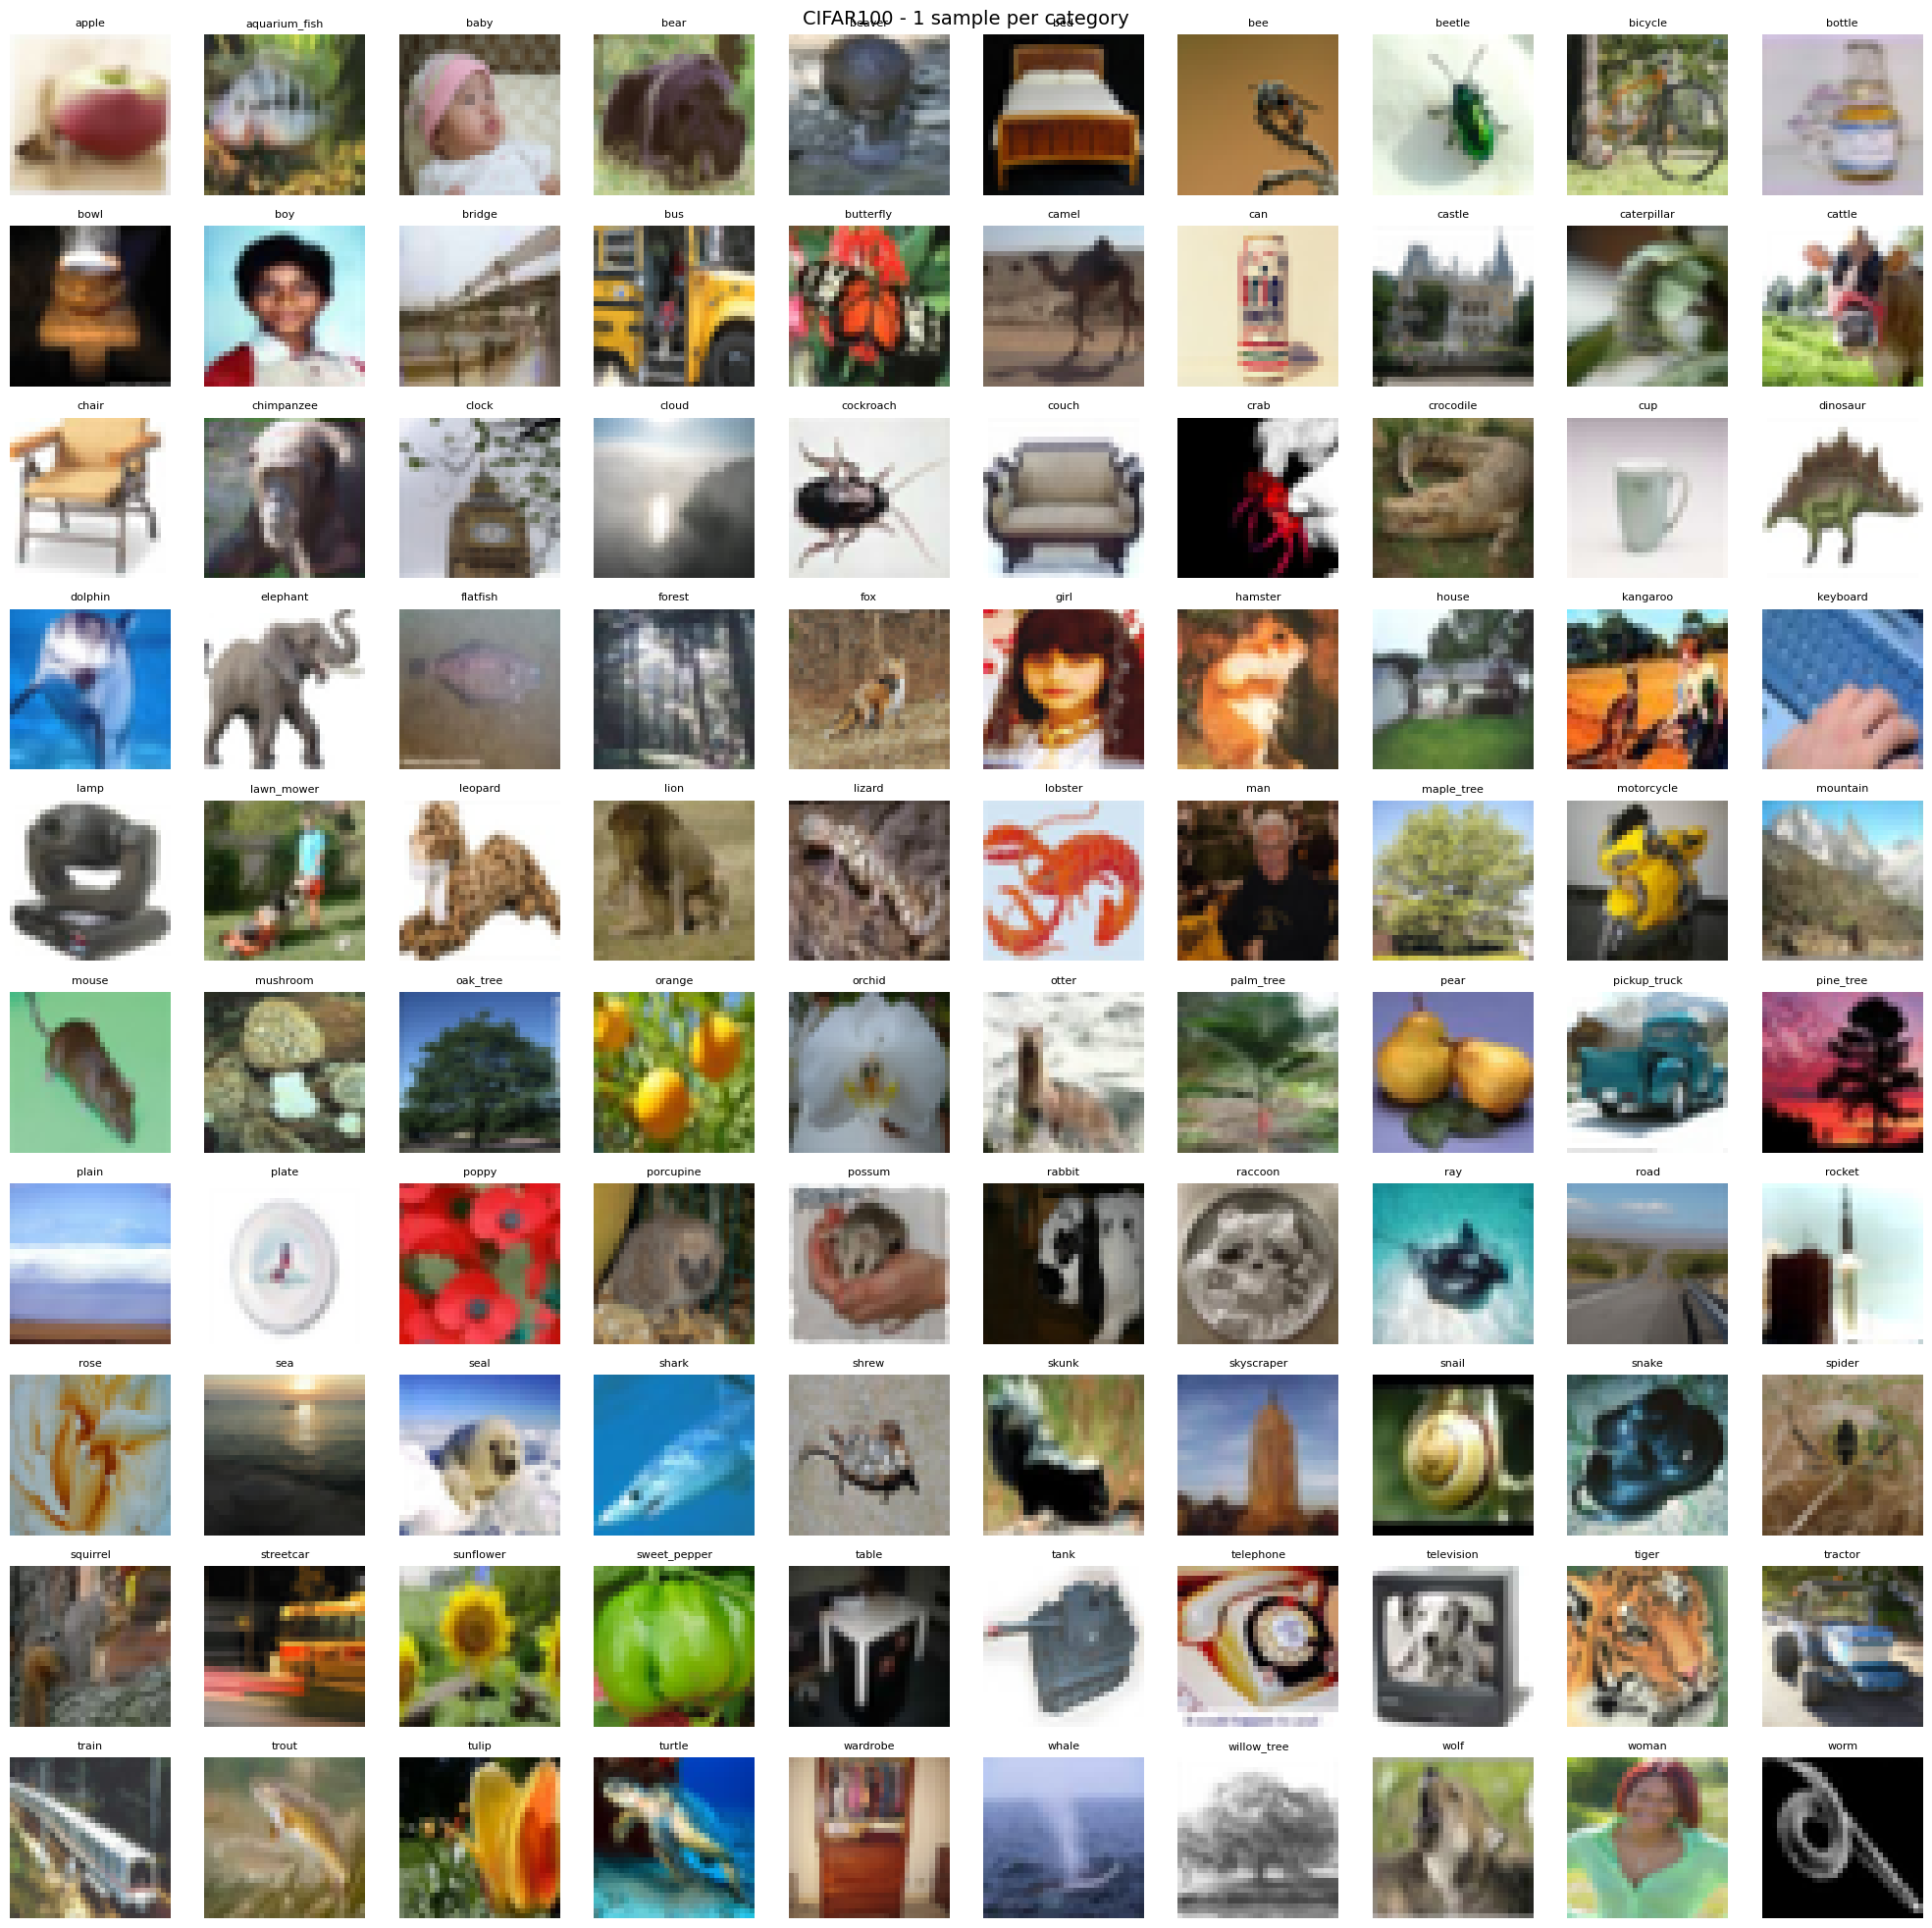

MNIST 카테고리 개수: 10


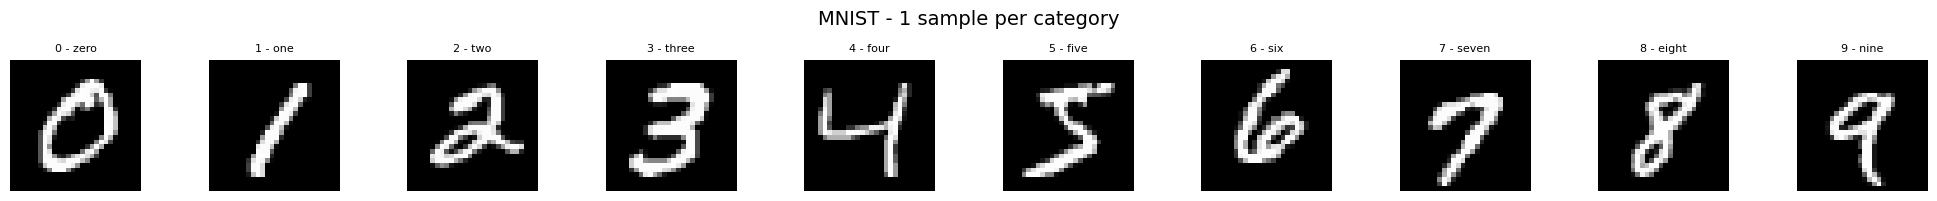

In [2]:
# --------------------------------------------------
# 데이터셋 정보 출력
# --------------------------------------------------
print_dataset_info("CIFAR100", cifar_train, cifar_test)
print_dataset_info("MNIST", mnist_train, mnist_test)

# --------------------------------------------------
# 각 카테고리별로 1개의 샘플 이미지를 시각화
# --------------------------------------------------
visualize_one_per_category(cifar_train, dataset_name="CIFAR100", cmap=None)
visualize_one_per_category(mnist_train, dataset_name="MNIST", cmap='gray')


두 방법의 최대 차이 (Max Difference): 0.0
두 방법의 평균 차이 (Mean Difference): 0.0


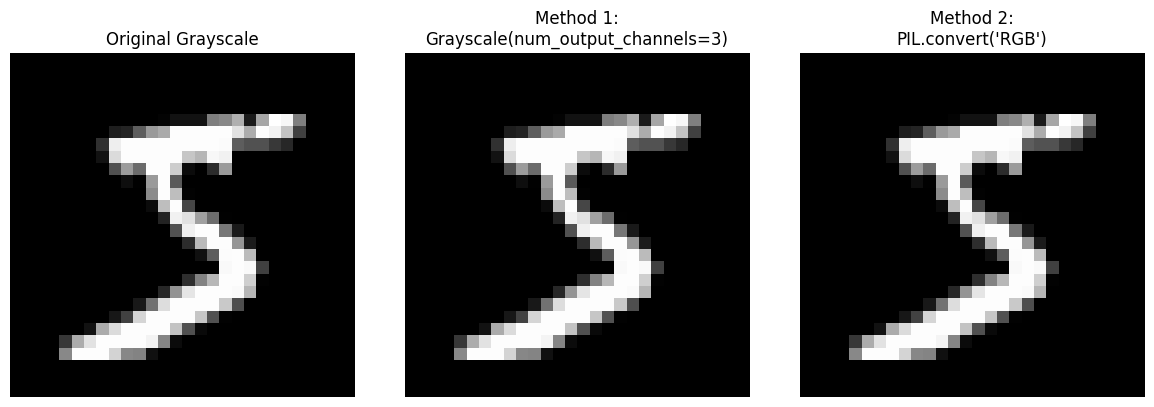

In [4]:
# MNIST 데이터셋에서 첫 번째 이미지 로드 (그레이스케일)
gray_img_array = mnist_train.data[0].numpy()  # shape: [28, 28]
gray_img_pil = Image.fromarray(gray_img_array, mode='L')  # PIL 이미지, 모드 'L' (그레이스케일)

# 3채널 데이터로 변환
# 방법 1: transforms.Grayscale(num_output_channels=3) 사용
transform_to3 = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor()
])
img_method1 = transform_to3(gray_img_pil)  # 텐서 shape: [3, 28, 28]

# 방법 2: PIL의 convert("RGB") 사용 후 ToTensor()
img_method2 = transforms.ToTensor()(gray_img_pil.convert("RGB"))  # 텐서 shape: [3, 28, 28]

# 두 결과의 차이 계산
diff = torch.abs(img_method1 - img_method2)
max_diff = diff.max().item()
mean_diff = diff.mean().item()

print("두 방법의 최대 차이 (Max Difference):", max_diff)
print("두 방법의 평균 차이 (Mean Difference):", mean_diff)

# 시각화 (세 이미지: 원본, 방법1, 방법2)
def imshow_tensor(img_tensor, title=None):
    np_img = img_tensor.numpy().transpose(1, 2, 0)
    plt.imshow(np_img)
    if title:
        plt.title(title)
    plt.axis('off')

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(gray_img_pil, cmap='gray')
plt.title("Original Grayscale")
plt.axis('off')

plt.subplot(1, 3, 2)
imshow_tensor(img_method1, title="Method 1:\nGrayscale(num_output_channels=3)")

plt.subplot(1, 3, 3)
imshow_tensor(img_method2, title="Method 2:\nPIL.convert('RGB')")

plt.tight_layout()
plt.show()


In [ ]:
num_features = 3
sequence_length = 10
batch_size = 2
x = torch.randn(batch_size, sequence_length, num_features)

lstm_layer = nn.LSTM(
    input_size=num_features,
    hidden_size=8,
    num_layers=4,
    batch_first=True,
)

output, (h_n, c_n) = lstm_layer(x)

In [7]:
print("Output shape:", output.shape)  # (batch_size, sequence_length, hidden_size)

Output shape: torch.Size([2, 10, 8])


In [8]:
print('h_n shape:', h_n.shape)  # (num_layers, batch_size, hidden_size)

h_n shape: torch.Size([4, 2, 8])


In [9]:
print('c_n shape:', c_n.shape)  # (num_layers, batch_size, hidden_size)

c_n shape: torch.Size([4, 2, 8])


In [11]:
# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == 'cpu':
    # macOS에서 MPS 사용 가능 여부 확인
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

mps


In [12]:
# @title 간단한 CNN 모델 정의

class SimpleCNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.features = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1), # 3ch --> 32ch
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(2), # 32x32 --> 16x16

        nn.Conv2d(32, 64, kernel_size=3, padding=1), # 32ch -->64ch
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2), # 16x16 --> 8x8

        nn.Conv2d(64, 128, kernel_size=3, padding=1), # 64ch --> 128ch
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(2) # 8x8 --> 4x4
    )
    self.classifier = nn.Sequential(
        nn.Linear(128*4*4, 256),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(256, 100)
    )

  def forward(self, x):
    x = self.features(x)
    x = x.view(x.size(0), -1) # flatten  (batch, 128x4x4)-->size()
    x = self.classifier(x)
    return x


In [20]:
# @title 학습 함수
def train_epoch(model, dataloader, loss_fn, opt):
  model.train()
  model.to(device)
  running_loss = 0 # 학습 loss 계산
  correct = 0 # Acc 계산
  total = 0 # 전체 데이터 크기

  for inputs, labels in tqdm(dataloader, leave=False, desc="Train"):
    inputs, labels = inputs.to(device), labels.to(device)
    opt.zero_grad()
    outputs = model(inputs)
    loss = loss_fn(outputs, labels)
    loss.backward()
    opt.step()

    running_loss += loss.item() * inputs.size(0) # 배치당 평균 loss x 배치 사이즈 --> 배치 내 모든 loss
    _, preds = torch.max(outputs, 1)
    correct += (preds == labels).sum().item()
    total += labels.size(0)

  epoch_loss = running_loss / total
  epoch_acc = correct / total

  return epoch_loss, epoch_acc

In [21]:
# @title 검증 함수
def val_epoch(model, dataloader, loss_fn):
  model.eval()
  model.to(device)
  running_loss = 0
  correct = 0
  total = 0

  with torch.no_grad():
    for inputs, labels in tqdm(dataloader, leave=False, desc='Val'):
      inputs, labels = inputs.to(device), labels.to(device)
      outputs = model(inputs)
      loss = loss_fn(outputs, labels)

      running_loss += loss.item() * inputs.size(0) # 배치당 평균 loss x 배치 사이즈 --> 배치 내 모든 loss
      _, preds = torch.max(outputs, dim=1)
      correct += (preds == labels).sum().item()
      total += labels.size(0)

  epoch_loss = running_loss / total
  epoch_acc = correct / total
  return epoch_loss, epoch_acc


In [22]:
# @title CIFAR-100 사전학습
trainsform_cifar = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5071, 0.4867, 0.4408],
                         std=[0.2675, 0.2565, 0.2761])
    ])

cifar_full = torchvision.datasets.CIFAR100(root='./data', train=True,
                                           transform=trainsform_cifar,
                                           download=True)
train_size = int(0.9 * len(cifar_full))
val_size = int(len(cifar_full)-train_size)

# 데이터셋 + 데이터로더
cifar_train, cifar_val = random_split(cifar_full, [train_size, val_size])
cifar_train_loader = DataLoader(cifar_train, batch_size=128, shuffle=True, num_workers=2)
cifal_val_loader = DataLoader(cifar_val, batch_size=128, shuffle=False, num_workers=2)

# 모델 정의
model_cifar = SimpleCNN().to(device)
loss_fn_cifar = nn.CrossEntropyLoss()
opt_cifar = optim.Adam(model_cifar.parameters(), lr=0.001)

# 학습
num_epochs = 5
for epoch in range(num_epochs):
  print(f"\n Epoch {epoch+1}/{num_epochs}")
  train_loss, train_acc = train_epoch(model_cifar,
                                      cifar_train_loader,
                                      loss_fn_cifar,
                                      opt_cifar)
  val_loss, val_acc = val_epoch(model_cifar,
                                cifal_val_loader,
                                loss_fn_cifar)
  print(f"Train Loss : {train_loss} // Train Acc : {train_acc}")
  print(f"Val Loss : {val_loss} // Val Acc : {val_acc}")




 Epoch 1/5


Train Loss : 4.021559383265178 // Train Acc : 0.07953333333333333
Val Loss : 3.447503564453125 // Val Acc : 0.1752

 Epoch 2/5


Train Loss : 3.5052024171617298 // Train Acc : 0.14742222222222223
Val Loss : 3.120553275680542 // Val Acc : 0.232

 Epoch 3/5


Train Loss : 3.2780481335957843 // Train Acc : 0.18793333333333334
Val Loss : 2.881643532180786 // Val Acc : 0.2826

 Epoch 4/5


Train Loss : 3.145563718838162 // Train Acc : 0.20915555555555557
Val Loss : 2.764355278015137 // Val Acc : 0.3072

 Epoch 5/5


Train Loss : 3.038156643210517 // Train Acc : 0.22633333333333333
Val Loss : 2.6398898834228515 // Val Acc : 0.3248


In [24]:
os.makedirs('./models', exist_ok=True)
torch.save(model_cifar.state_dict(), './models/model_cifar100.pth')

In [25]:
model_cifar

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=2048, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in

In [26]:
model_cifar.features[11]

MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)

In [27]:
model_cifar.classifier

Sequential(
  (0): Linear(in_features=2048, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=256, out_features=100, bias=True)
)

In [28]:
model_cifar.classifier[3]

Linear(in_features=256, out_features=100, bias=True)

In [29]:
# @title MINIST 데이터 전처리
transform_mnist = transforms.Compose([
    transforms.Resize(32),  # 이미지 resize 28x28 --> 32x32
    transforms.Grayscale(num_output_channels=3), # 이미지 ch 변경 1ch --> 3ch
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std = [0.5, 0.5, 0.5])

    ])

mnist_full = torchvision.datasets.MNIST(root='./data',
                                        train=True,
                                        download=True,
                                        transform=transform_mnist)

mnist_train_size = int(0.9* len(mnist_full))
mnist_val_size = int(len(mnist_full)-mnist_train_size)

mnist_train, mnist_val = random_split(mnist_full, [mnist_train_size, mnist_val_size])
mnist_train_loader = DataLoader(mnist_train, batch_size=128, shuffle=True, num_workers=2)
mnist_val_loader = DataLoader(mnist_val, batch_size=128, shuffle=False, num_workers=2)



In [30]:
# @title MNIST Full Fine_tuning (전체 레이어 업데이트)

# MNIST 모델 생성 --> CIFAR100 구조를 기준으로
model_mnist_ft = SimpleCNN().to(device)

# CIFAR100 모델의 parameter 로드
model_cifar_dict = torch.load('./models/model_cifar100.pth', map_location=device)

# MNIST 모델의 구조를 복사
model_dict = model_mnist_ft.state_dict()

# pretrained 모델에서 features만 저장 --> pretrained_dict
pretrained_dict = {k: v for k,v in model_cifar_dict.items() if k.startswith('features')}

# MNIST 모델 구조에 pretrained_dict를 업데이트
model_dict.update(pretrained_dict)

# MNIST 모델에 pretrained_dict parameter를 로드
model_mnist_ft.load_state_dict(model_dict)


<All keys matched successfully>

In [31]:
model_mnist_ft.classifier[3] = nn.Linear(256, 10).to(device)

In [32]:
model_mnist_ft.classifier[3] = nn.Linear(256, 10).to(device)
model_mnist_ft.classifier

Sequential(
  (0): Linear(in_features=2048, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=256, out_features=10, bias=True)
)

In [33]:
print("MNIST full Fine Tuning model", model_mnist_ft)

MNIST full Fine Tuning model SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=2048, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inpl

In [34]:
opt_mnist_ft = optim.Adam(model_mnist_ft.parameters(), lr=0.0001)
loss_fn_mnist = nn.CrossEntropyLoss()

In [ ]:
# metric 저장을 위한 리스트
ft_train_losses, ft_train_accs = [],[]
ft_val_losses, ft_val_accs = [], []

num_epochs_mnist = 3
for epoch in range(num_epochs_mnist):
  print(f"\nMNIST Full Fine_tune Epoch {epoch+1}/{num_epochs_mnist}")
  train_loss, train_acc = train_epoch(model_mnist_ft, mnist_train_loader, loss_fn_mnist, opt_mnist_ft)
  val_loss, val_acc = val_epoch(model_mnist_ft, mnist_val_loader, loss_fn_mnist)
  print(f"Train Loss : {train_loss:.4f} // Train Acc : {train_acc:.4f}")
  print(f"Val Loss : {val_loss:.4f} // Val Acc : {val_acc:.4f}")

  ft_train_losses.append(train_loss)
  ft_train_accs.append(train_acc)
  ft_val_losses.append(val_loss)
  ft_val_accs.append(val_acc)




MNIST Full Fine_tune Epoch 1/3


Train Loss : 0.3549 // Train Acc : 0.9125
Val Loss : 0.0766 // Val Acc : 0.9787

MNIST Full Fine_tune Epoch 2/3


Train Loss : 0.0798 // Train Acc : 0.9770
Val Loss : 0.0482 // Val Acc : 0.9865

MNIST Full Fine_tune Epoch 3/3


Train Loss : 0.0540 // Train Acc : 0.9843
Val Loss : 0.0397 // Val Acc : 0.9882


In [36]:
# @title MNIST Feature Extraction (classifier만 업데이트)

model_mnist_fe = SimpleCNN().to(device)
model_dict_fe = model_mnist_fe.state_dict()
pretrained_dict_fe = {k:v for k,v in model_cifar_dict.items() if k.startswith("features")}
model_dict_fe.update(pretrained_dict_fe)
model_mnist_fe.load_state_dict(model_dict_fe)


<All keys matched successfully>

In [37]:
# Feature Extractor 고정
for param in model_mnist_fe.features.parameters():
  param.requires_grad = False

In [38]:
# Feature Extractor 고정 확인
for name, param in model_mnist_fe.named_parameters():
  print(f"{name} : {param.requires_grad}")
print("\n")

features.0.weight : False
features.0.bias : False
features.1.weight : False
features.1.bias : False
features.4.weight : False
features.4.bias : False
features.5.weight : False
features.5.bias : False
features.8.weight : False
features.8.bias : False
features.9.weight : False
features.9.bias : False
classifier.0.weight : True
classifier.0.bias : True
classifier.3.weight : True
classifier.3.bias : True




In [39]:
model_mnist_fe.classifier[3] = nn.Linear(256, 10).to(device)

model_mnist_fe.classifier = nn.Sequential(
    nn.Linear(128*4*4, 128),
    nn.ReLU(),
    nn.Linear(128,10)
)

In [40]:
print(model_mnist_fe)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=2048, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=Tr

In [41]:
opt_mnist_fe = optim.Adam(model_mnist_fe.classifier.parameters(), lr=0.001)

# metric 저장을 위한 리스트
fe_train_losses, fe_train_accs = [],[]
fe_val_losses, fe_val_accs = [], []

num_epochs_mnist = 3
for epoch in range(num_epochs_mnist):
  print(f"\nMNIST Full Fine_tune Epoch {epoch+1}/{num_epochs_mnist}")
  train_loss, train_acc = train_epoch(model_mnist_fe, mnist_train_loader, loss_fn_mnist, opt_mnist_fe)
  val_loss, val_acc = val_epoch(model_mnist_fe, mnist_val_loader, loss_fn_mnist)
  print(f"Train Loss : {train_loss:.4f} // Train Acc : {train_acc:.4f}")
  print(f"Val Loss : {val_loss:.4f} // Val Acc : {val_acc:.4f}")

  fe_train_losses.append(train_loss)
  fe_train_accs.append(train_acc)
  fe_val_losses.append(val_loss)
  fe_val_accs.append(val_acc)



MNIST Full Fine_tune Epoch 1/3


Train Loss : 0.1506 // Train Acc : 0.9580
Val Loss : 0.0586 // Val Acc : 0.9818

MNIST Full Fine_tune Epoch 2/3


Train Loss : 0.0546 // Train Acc : 0.9833
Val Loss : 0.0495 // Val Acc : 0.9838

MNIST Full Fine_tune Epoch 3/3


Train Loss : 0.0418 // Train Acc : 0.9870
Val Loss : 0.0409 // Val Acc : 0.9858


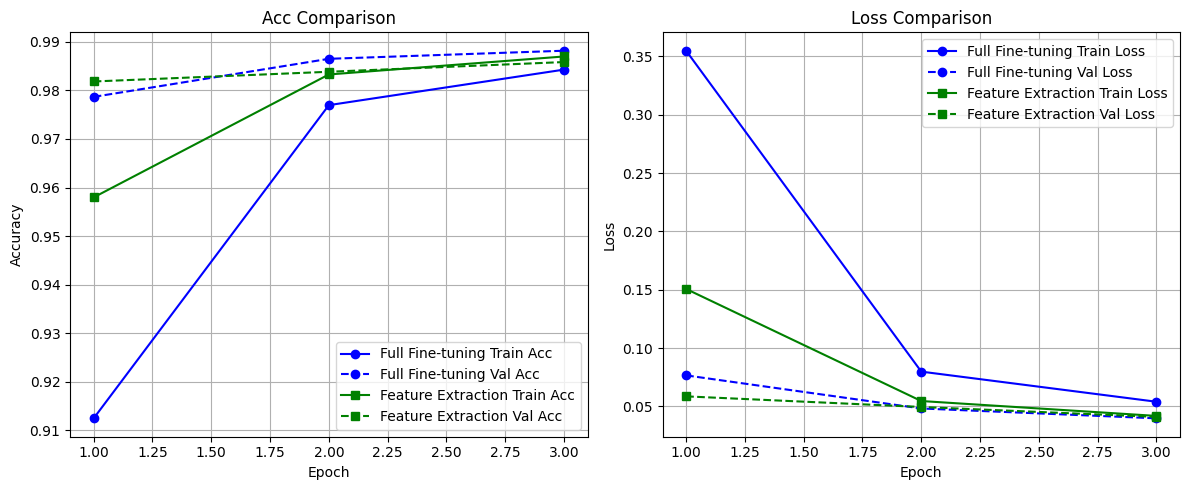

In [43]:
# @title 성능비교 Plot (Accuracy & Loss)

epochs = range(1, num_epochs_mnist+1)

plt.figure(figsize=(12,5))

#Accuracy
plt.subplot(1,2,1)
plt.plot(epochs, ft_train_accs, 'o-', c='b', label="Full Fine-tuning Train Acc")
plt.plot(epochs, ft_val_accs, 'o--', c='b', label="Full Fine-tuning Val Acc")
plt.plot(epochs, fe_train_accs, 's-', c='g', label="Feature Extraction Train Acc")
plt.plot(epochs, fe_val_accs, 's--', c='g', label="Feature Extraction Val Acc")

plt.xlabel('Epoch')
plt.ylabel("Accuracy")
plt.title("Acc Comparison")
plt.legend()
plt.grid(True)

#Loss
plt.subplot(1,2,2)
plt.plot(epochs, ft_train_losses, 'o-', c='b', label="Full Fine-tuning Train Loss")
plt.plot(epochs, ft_val_losses, 'o--', c='b', label="Full Fine-tuning Val Loss")
plt.plot(epochs, fe_train_losses, 's-', c='g', label="Feature Extraction Train Loss")
plt.plot(epochs, fe_val_losses, 's--', c='g', label="Feature Extraction Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Comparison")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()